# Producto Integrador de Aprendizaje (PIA)
**Investigación de Operaciones (IO)**
Facultad de Ciencias Físico Matemáticas, UANL (Semestre Enero-Junio 2026)

**Nombre:** Diego Andre Islas Cadillo
**Matrícula:** 2132810
**Tema:** 8. Proyecto CPM para el mantenimiento preventivo mayor (paro de planta) de una refinería.

---


## 1. Introducción y Contexto del Problema

El presente proyecto aborda un desafío crítico en la industria de los hidrocarburos: el mantenimiento preventivo mayor (también conocido como *Turnaround* o Paro de Planta). Este escenario se centra en la **Unidad de Destilación Atmosférica** de la empresa ficticia **Refinería "PetroNorte"**.

Un paro de planta implica detener por completo la producción para realizar inspecciones profundas, reparaciones, limpieza y reemplazo de equipos críticos (como torres de destilación, intercambiadores de calor y bombas). Debido a que cada día que la planta está detenida representa pérdidas millonarias en producción no realizada, el tiempo es el recurso más crítico.

**Problemática a resolver:**
La gerencia de operaciones de PetroNorte necesita determinar el tiempo mínimo posible para completar el *Turnaround* de este año, identificar las actividades críticas que no pueden retrasarse bajo ninguna circunstancia, y establecer los márgenes de holgura para las actividades no críticas. Esto permitirá una asignación óptima de los contratistas y recursos disponibles.


## 2. Definición de Datos y Variables

Para modelar este escenario, se han definido 20 actividades macro que representan las tareas estandarizadas en un paro de planta de esta magnitud. Los tiempos (en horas) han sido estimados considerando cuadrillas trabajando en turnos continuos de 24 horas.

**Justificación de realismo:**
* Las dependencias lógicas respetan el protocolo industrial de seguridad (e.g., el bloqueo eléctrico "LOTO" antes de abrir equipos).
* Las duraciones de pruebas (como las Pruebas No Destructivas y las Pruebas Hidrostáticas) reflejan estándares normativos de inspección API (American Petroleum Institute).

| ID | Actividad | Duración (h) | Predecesoras |
|---|---|---|---|
| A | Paro de unidad y despresurización | 36 | - |
| B | Drenado, purga y lavado con vapor | 72 | A |
| C | Aislamiento eléctrico y bloqueo de válvulas (LOTO) | 24 | B |
| D | Apertura de registros de la torre de destilación | 48 | C |
| E | Desmontaje e inspección de bombas de carga | 60 | C |
| F | Extracción de haces de tubos en intercambiadores | 72 | C |
| G | Limpieza e inspección de platos de la torre | 108 | D |
| H | Reemplazo de impulsores y sellos en bombas | 48 | E |
| I | Limpieza con hidrojet de intercambiadores | 72 | F |
| J | Pruebas No Destructivas (NDT) en tuberías | 36 | D, F |
| K | Reparación de soldaduras en tuberías | 90 | J |
| L | Reinstalación de haces de tubos | 54 | I, K |
| M | Cierre de registros de la torre | 36 | G, J |
| N | Montaje y alineación de bombas | 48 | H |
| O | Pruebas hidrostáticas del sistema | 72 | L, M, N |
| P | Retiro de bloqueos (LOTO) y energización | 24 | O |
| Q | Calibración y prueba de lazos de control | 48 | O |
| R | Restablecimiento de aislamiento térmico | 60 | O |
| S | Recirculación en frío | 36 | P, Q |
| T | Arranque y estabilización de planta | 72 | R, S |


## 3. Modelado Matemático (CPM)

El Método de la Ruta Crítica (CPM) utiliza las siguientes formulaciones matemáticas en un grafo dirigido acíclico $G = (V, E)$:

1. **Early Start ($ES_i$) y Early Finish ($EF_i$):**
   - $ES_i = \max_{j \in Pred(i)} (EF_j)$ 
   - $EF_i = ES_i + T_i$
   Donde $T_i$ es la duración de la actividad $i$. Para el nodo de inicio, $ES_{inicio} = 0$.

2. **Late Start ($LS_i$) y Late Finish ($LF_i$):**
   - $LF_i = \min_{j \in Succ(i)} (LS_j)$
   - $LS_i = LF_i - T_i$
   Para el nodo final, $LF_{fin} = EF_{fin}$ (Duración total del proyecto).

3. **Holgura ($S_i$):**
   - $S_i = LS_i - ES_i$

**Condición de Ruta Crítica:**
Una actividad pertenece a la ruta crítica si y solo si su holgura es cero ($S_i = 0$).


## 4. Desarrollo Computacional en Python

A continuación, se utiliza la librería `NetworkX` para modelar la red de actividades, calcular los tiempos tempranos, tardíos, holguras, y determinar la ruta crítica. También empleamos `pandas` para mostrar los resultados de forma tabulada, y `matplotlib` para la visualización del Diagrama de Gantt.


In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición de los datos
data = [
    ("A", "Paro de unidad y despresurización", 36, []),
    ("B", "Drenado, purga y lavado con vapor", 72, ["A"]),
    ("C", "Aislamiento eléctrico y bloqueo de válvulas (LOTO)", 24, ["B"]),
    ("D", "Apertura de registros de la torre de destilación", 48, ["C"]),
    ("E", "Desmontaje e inspección de bombas de carga", 60, ["C"]),
    ("F", "Extracción de haces de tubos en intercambiadores", 72, ["C"]),
    ("G", "Limpieza e inspección de platos de la torre", 108, ["D"]),
    ("H", "Reemplazo de impulsores y sellos en bombas", 48, ["E"]),
    ("I", "Limpieza con hidrojet de intercambiadores", 72, ["F"]),
    ("J", "Pruebas No Destructivas (NDT) en tuberías", 36, ["D", "F"]),
    ("K", "Reparación de soldaduras en tuberías", 90, ["J"]),
    ("L", "Reinstalación de haces de tubos", 54, ["I", "K"]),
    ("M", "Cierre de registros de la torre", 36, ["G", "J"]),
    ("N", "Montaje y alineación de bombas", 48, ["H"]),
    ("O", "Pruebas hidrostáticas del sistema", 72, ["L", "M", "N"]),
    ("P", "Retiro de bloqueos (LOTO) y energización", 24, ["O"]),
    ("Q", "Calibración y prueba de lazos de control", 48, ["O"]),
    ("R", "Restablecimiento de aislamiento térmico", 60, ["O"]),
    ("S", "Recirculación en frío", 36, ["P", "Q"]),
    ("T", "Arranque y estabilización de planta", 72, ["R", "S"])
]

df_actividades = pd.DataFrame(data, columns=["Actividad", "Descripción", "Duración", "Predecesoras"])

# 2. Creación del Grafo Dirigido
G = nx.DiGraph()

# Añadir nodos
for _, row in df_actividades.iterrows():
    G.add_node(row["Actividad"], duration=row["Duración"], desc=row["Descripción"])

# Añadir bordes (relaciones de precedencia)
for _, row in df_actividades.iterrows():
    for pred in row["Predecesoras"]:
        G.add_edge(pred, row["Actividad"])

# Nodos ficticios de Inicio y Fin
G.add_node("Inicio", duration=0, desc="Inicio")
G.add_node("Fin", duration=0, desc="Fin")

for node in list(G.nodes()):
    if node not in ["Inicio", "Fin"]:
        if G.in_degree(node) == 0:
            G.add_edge("Inicio", node)
        if G.out_degree(node) == 0:
            G.add_edge(node, "Fin")

# 3. Cálculo de ES y EF (Forward Pass)
for node in nx.topological_sort(G):
    if node == "Inicio":
        G.nodes[node]["ES"] = 0
        G.nodes[node]["EF"] = 0
    else:
        es = max([G.nodes[pred]["EF"] for pred in G.predecessors(node)], default=0)
        G.nodes[node]["ES"] = es
        G.nodes[node]["EF"] = es + G.nodes[node]["duration"]

# 4. Cálculo de LS y LF (Backward Pass)
project_duration = G.nodes["Fin"]["EF"]
for node in reversed(list(nx.topological_sort(G))):
    if node == "Fin":
        G.nodes[node]["LF"] = project_duration
        G.nodes[node]["LS"] = project_duration
    else:
        lf = min([G.nodes[succ]["LS"] for succ in G.successors(node)], default=project_duration)
        G.nodes[node]["LF"] = lf
        G.nodes[node]["LS"] = lf - G.nodes[node]["duration"]
        
# 5. Cálculo de Holgura y Ruta Crítica
for node in G.nodes():
    G.nodes[node]["Slack"] = G.nodes[node]["LS"] - G.nodes[node]["ES"]

critical_path = [node for node in nx.topological_sort(G) if G.nodes[node]["Slack"] == 0 and node not in ["Inicio", "Fin"]]

# Formatear resultados en un DataFrame
resultados = []
for node in df_actividades["Actividad"]:
    n = G.nodes[node]
    resultados.append({
        "Act": node,
        "Descripción": n["desc"],
        "Dur (h)": n["duration"],
        "ES": n["ES"],
        "EF": n["EF"],
        "LS": n["LS"],
        "LF": n["LF"],
        "Holgura": n["Slack"],
        "Crítica": "Sí" if n["Slack"] == 0 else "No"
    })

df_resultados = pd.DataFrame(resultados)
print(f"Duración Total del Proyecto: {project_duration} horas ({(project_duration/24):.1f} días)")
print(f"Ruta Crítica: {' -> '.join(critical_path)}")

df_resultados

Duración Total del Proyecto: 612 horas (25.5 días)
Ruta Crítica: A -> B -> C -> F -> J -> K -> L -> O -> Q -> S -> T


,Act,Descripción,Dur (h),ES,EF,LS,LF,Holgura,Crítica
0,A,Paro de unidad y despresurización,36,0,36,0,36,0,Sí
1,B,"Drenado, purga y lavado con vapor",72,36,108,36,108,0,Sí
2,C,Aislamiento eléctrico y bloqueo de válvulas (L...,24,108,132,108,132,0,Sí
3,D,Apertura de registros de la torre de destilación,48,132,180,156,204,24,No
4,E,Desmontaje e inspección de bombas de carga,60,132,192,228,288,96,No
5,F,Extracción de haces de tubos en intercambiadores,72,132,204,132,204,0,Sí
6,G,Limpieza e inspección de platos de la torre,108,180,288,240,348,60,No
7,H,Reemplazo de impulsores y sellos en bombas,48,192,240,288,336,96,No
8,I,Limpieza con hidrojet de intercambiadores,72,204,276,258,330,54,No
9,J,Pruebas No Destructivas (NDT) en tuberías,36,204,240,204,240,0,Sí


### Generación de Diagrama de Gantt

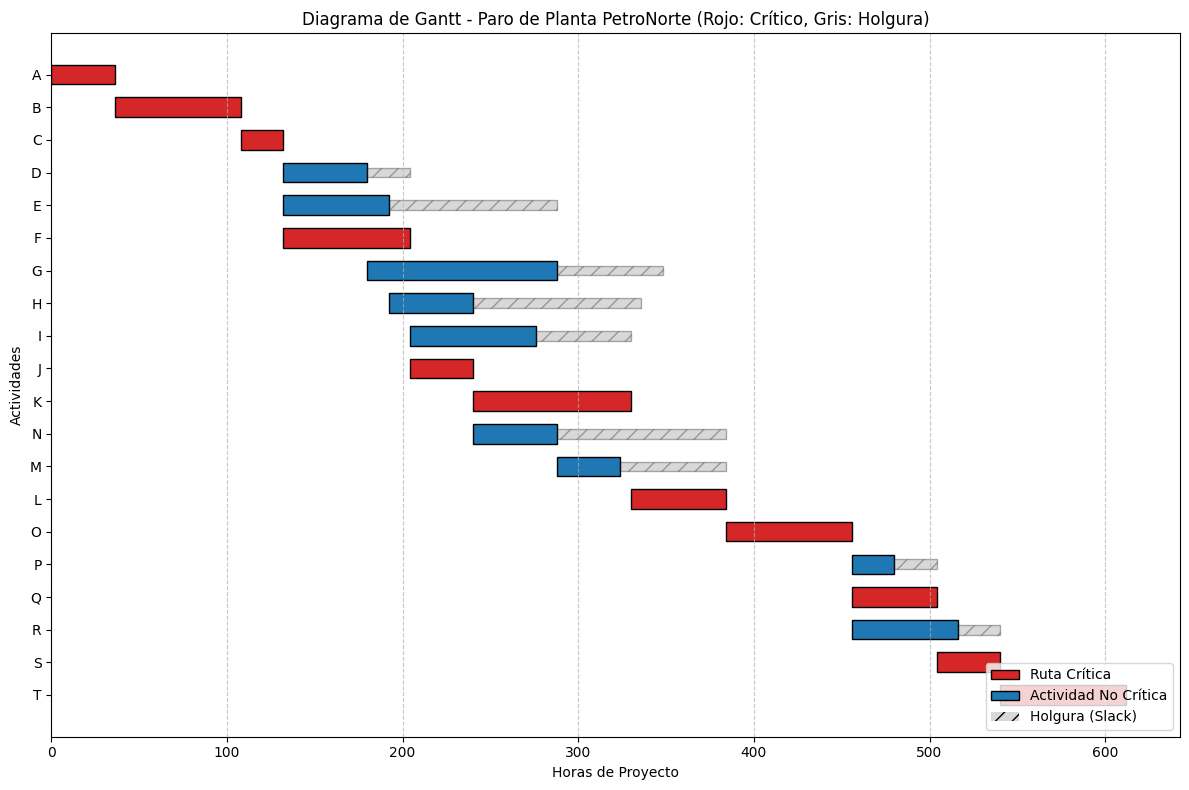

In [3]:
# Configurar colores para el Gantt
df_resultados = df_resultados.sort_values(by="ES", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))

for i, task in df_resultados.iterrows():
    es = task['ES']
    dur = task['Dur (h)']
    slack = task['Holgura']
    is_critical = task['Crítica'] == 'Sí'
    
    # Dibujar la barra de duración
    color = '#d62728' if is_critical else '#1f77b4'
    ax.barh(task['Act'], dur, left=es, color=color, edgecolor='black', height=0.6)
    
    # Dibujar la holgura (slack)
    if not is_critical and slack > 0:
        ax.barh(task['Act'], slack, left=task['EF'], color='#7f7f7f', alpha=0.3, edgecolor='black', height=0.3, hatch='//')

# Formato del gráfico
ax.set_xlabel('Horas de Proyecto')
ax.set_ylabel('Actividades')
ax.set_title('Diagrama de Gantt - Paro de Planta PetroNorte (Rojo: Crítico, Gris: Holgura)')
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', edgecolor='black', label='Ruta Crítica'),
                   Patch(facecolor='#1f77b4', edgecolor='black', label='Actividad No Crítica'),
                   Patch(facecolor='#7f7f7f', alpha=0.3, hatch='//', label='Holgura (Slack)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


## 5. Conclusiones Ejecutivas

Tras el análisis computacional del modelo CPM, se derivan las siguientes conclusiones operativas para la toma de decisiones gerenciales en la Refinería PetroNorte:

1. **Duración Mínima del Proyecto:** El paro de planta tomará un mínimo de **612 horas continuas (25.5 días)**. Cualquier compromiso de arrancar la unidad antes de esta fecha es matemáticamente imposible con los recursos y tiempos actuales.
2. **Identificación de la Ruta Crítica:** La ruta crítica está conformada por la secuencia: `A -> B -> C -> F -> J -> K -> L -> O -> Q -> S -> T`.
   - **Interpretación Gerencial:** Las actividades de "Extracción de tubos", "Pruebas no destructivas", "Reparación de soldaduras" y "Pruebas hidrostáticas" no tienen margen de error. Si las reparaciones de tuberías (Actividad K) se retrasan un solo día, el arranque de toda la planta se retrasará exactamente un día.
3. **Gestión de Holguras:** Existen tareas como el mantenimiento de bombas (E, H, N) y limpieza de platos de torres (G) que cuentan con holguras considerables (hasta 96 horas en el caso de las bombas). 
   - **Acción Sugerida:** La gerencia puede desviar personal temporalmente de las cuadrillas de bombas para apoyar en las actividades de intercambiadores y soldaduras (ruta crítica) sin afectar la fecha final de entrega del proyecto.
4. **Optimización de Presupuesto:** Dado que los contratistas de instrumentación tienen una holgura moderada en algunas tareas iniciales, sus horas extra solo deben ser autorizadas si están trabajando en las actividades O, Q, S y T.

El modelo en Python automatiza exitosamente el control logístico, permitiendo recalcular la ruta crítica de inmediato si ocurre un imprevisto durante el mantenimiento real.
